Saved Binary GC matrix:
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 

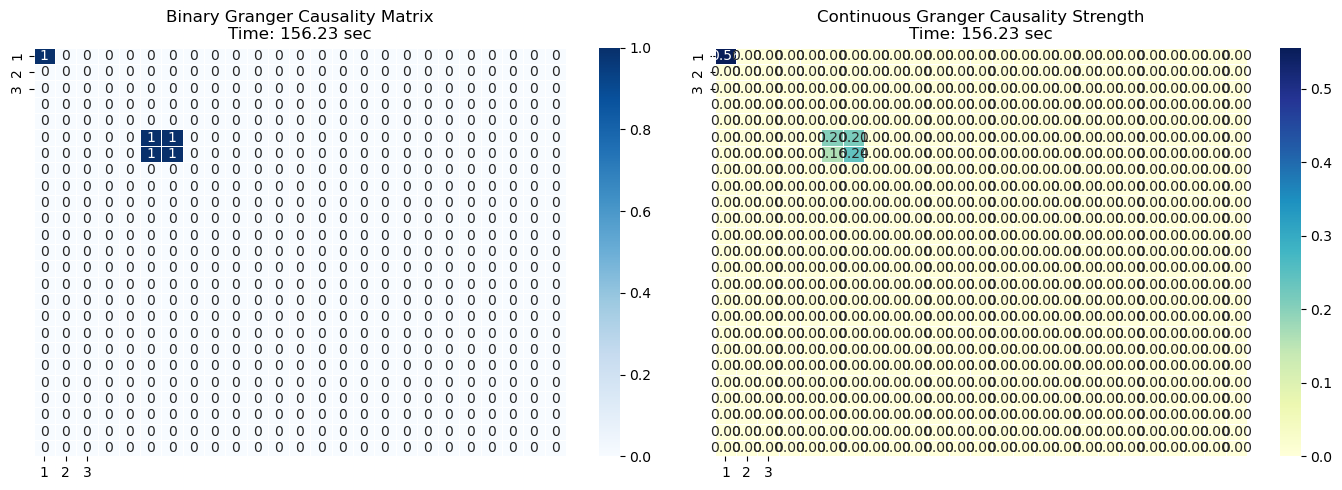

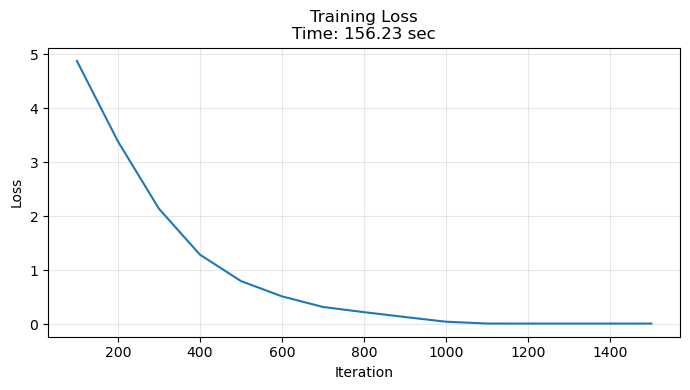

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_dir = "/data/mydongh/Neural-GC/results/SMAP(lag5,iter1000,lam0.07)"
GC = np.load(f"{save_dir}/gc_binary.npy")
GC_strength = np.load(f"{save_dir}/gc_strength.npy")
elapsed_time = np.load(f"{save_dir}/elapsed_time.npy")

print("Saved Binary GC matrix:")
print(GC)

print("\nSaved Continuous GC strength matrix:")
print(np.round(GC_strength, 4))

print(f"\nTraining time: {float(elapsed_time):.2f} sec ({float(elapsed_time)/60:.2f} min)")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    GC,
    annot=True,
    cmap="Blues",
    fmt=".0f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Binary Granger Causality Matrix\nTime: {float(elapsed_time):.2f} sec")

plt.subplot(1, 2, 2)
sns.heatmap(
    GC_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Continuous Granger Causality Strength\nTime: {float(elapsed_time):.2f} sec")

plt.tight_layout()
plt.show()

# ---------------------------
# loss plot
# ---------------------------
loss_path = f"{save_dir}/loss_history.npy"

if os.path.exists(loss_path):
    loss_history = np.load(loss_path)

    # iteration 생성 (100, 200, 300, ...)
    check_every = 100
    iterations = np.arange(1, len(loss_history) + 1) * check_every

    plt.figure(figsize=(7, 4))
    plt.plot(iterations, loss_history)   # ✅ marker 제거

    plt.title(f"Training Loss\nTime: {float(elapsed_time):.2f} sec")
    plt.xlabel("Iteration")              # ✅ 변경
    plt.ylabel("Loss")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("loss_history.npy가 저장되지 않았습니다. 현재 train_model_ista가 loss history를 반환하지 않는 버전일 수 있습니다.")